In [1]:
# ==========================================
# CELL 1 — WHAT THIS NOTEBOOK DOES
# ==========================================
# Notebook 9 found that filtering down to a small, high-confidence subset of
# days (regime-gated + NIFTY-confirmed + a strict NIFTY move-size cutoff)
# gives 89.5% accuracy on 38 days. This notebook does two things:
#
#   1. SWEEPS the strictness of that last filter from "no filter at all"
#      (the full 76-day agree bucket) up to "very strict" (a handful of
#      days), and plots exactly how accuracy trades off against how many
#      days you actually get to predict on.
#
#   2. DOCUMENTS every feature used anywhere in this pipeline - what it is,
#      where it's computed, and what role it plays - as a single reference
#      table and diagram.

import os
import glob
import numpy as np
import pandas as pd

folder = r"C:\Users\ASUS\Desktop\volPredict"

print("=== REBUILDING THE FULL PIPELINE (SAME LOGIC AS NOTEBOOK 9) ===")

sp500 = pd.read_csv(os.path.join(folder, "sp500_daily.csv"), parse_dates=["Date"])
sp500 = sp500[["Date", "Close"]].rename(columns={"Close": "SP500_Close"})
sp500 = sp500.dropna().sort_values("Date").reset_index(drop=True)

us_vix = pd.read_csv(os.path.join(folder, "vix_us_daily.csv"))
us_vix["Date"] = pd.to_datetime(us_vix["DATE"])
us_vix = us_vix[["Date", "CLOSE"]].rename(columns={"CLOSE": "US_VIX_Close"})
us_vix = us_vix.dropna().sort_values("Date").reset_index(drop=True)

us_market = pd.merge(sp500, us_vix, on="Date", how="outer").sort_values("Date").reset_index(drop=True)
us_market["SP500_LogReturn"] = np.log(us_market["SP500_Close"] / us_market["SP500_Close"].shift(1))
us_market["US_VIX_chg1d"] = us_market["US_VIX_Close"].diff(1)

iv_feat = pd.read_csv(os.path.join(folder, "daily_volatility_features.csv"), parse_dates=["Date"])
iv_feat = iv_feat.sort_values("Date").reset_index(drop=True)

df = pd.merge_asof(iv_feat, us_market, on="Date", direction="backward", allow_exact_matches=False)
df = df.rename(columns={
    "SP500_Close": "US_SP500_prev_close", "SP500_LogReturn": "US_SP500_prev_return",
    "US_VIX_Close": "US_VIX_prev_close", "US_VIX_chg1d": "US_VIX_prev_chg1d",
})
df["ATM_IV_30D_prev"] = df["ATM_IV_30D"].shift(1)
df["NIFTY_IV_chg1d"] = df["ATM_IV_30D"] - df["ATM_IV_30D_prev"]
df["SKEW_30D_prev"] = df["SKEW_30D"].shift(1)
df["SKEW_14D_prev"] = df["SKEW_14D"].shift(1)

fut_files = sorted(glob.glob(os.path.join(folder, "FUTIDX_NIFTY_*.csv")))
fut_list = []
for f in fut_files:
    d = pd.read_csv(f)
    d.columns = d.columns.str.strip()
    fut_list.append(d)
fut = pd.concat(fut_list, ignore_index=True)
fut["Date"] = pd.to_datetime(fut["Date"].str.strip(), format="%d-%b-%Y")
fut["Underlying Value"] = pd.to_numeric(fut["Underlying Value"].astype(str).str.strip(), errors="coerce")
nifty_spot = fut.dropna(subset=["Underlying Value"]).groupby("Date")["Underlying Value"].first().reset_index()
nifty_spot = nifty_spot.rename(columns={"Underlying Value": "NIFTY_Spot"}).sort_values("Date").reset_index(drop=True)
nifty_spot["NIFTY_prev_return"] = np.log(nifty_spot["NIFTY_Spot"] / nifty_spot["NIFTY_Spot"].shift(1))
df = pd.merge(df, nifty_spot[["Date", "NIFTY_prev_return"]], on="Date", how="left")

india_vix_files = sorted(glob.glob(os.path.join(folder, "hist_india_vix_*.csv")))
india_vix_list = []
for f in india_vix_files:
    d = pd.read_csv(f)
    d.columns = d.columns.str.strip()
    india_vix_list.append(d)
india_vix = pd.concat(india_vix_list, ignore_index=True)
india_vix["Date"] = pd.to_datetime(india_vix["Date"], dayfirst=True, errors="coerce")
india_vix = india_vix.rename(columns={"Close": "India_VIX_Close"})
india_vix = india_vix[["Date", "India_VIX_Close"]].dropna().sort_values("Date").reset_index(drop=True)
india_vix["India_VIX_Close"] = pd.to_numeric(india_vix["India_VIX_Close"], errors="coerce")
india_vix["India_VIX_prev_close"] = india_vix["India_VIX_Close"].shift(1)
india_vix["India_VIX_prev_chg1d"] = india_vix["India_VIX_prev_close"] - india_vix["India_VIX_Close"].shift(2)
df = pd.merge(df, india_vix[["Date", "India_VIX_prev_close", "India_VIX_prev_chg1d"]], on="Date", how="left")

LARGE_MOVE_THRESHOLD = df["US_VIX_prev_chg1d"].abs().quantile(0.75)
df["Large_US_Move_Flag"] = (df["US_VIX_prev_chg1d"].abs() >= LARGE_MOVE_THRESHOLD).astype("Int64")
df["NIFTY_IV_Up_Label"] = (df["NIFTY_IV_chg1d"] > 0).astype("Int64")

FEATURE_COLS = ["US_SP500_prev_return", "US_VIX_prev_close", "US_VIX_prev_chg1d",
                "SKEW_30D_prev", "SKEW_14D_prev",
                "India_VIX_prev_close", "India_VIX_prev_chg1d"]
TARGET_COL = "NIFTY_IV_Up_Label"

full_df = df[["Date", "Large_US_Move_Flag", "NIFTY_prev_return"] + FEATURE_COLS + [TARGET_COL]].dropna().reset_index(drop=True)
full_df[TARGET_COL] = full_df[TARGET_COL].astype(int)
full_df["Large_US_Move_Flag"] = full_df["Large_US_Move_Flag"].astype(int)
flagged_df = full_df[full_df["Large_US_Move_Flag"] == 1].reset_index(drop=True)

NIFTY_MEANINGFUL_MOVE_THRESHOLD = flagged_df["NIFTY_prev_return"].abs().quantile(0.25)
flagged_df["us_says_up_vol"] = flagged_df["US_VIX_prev_chg1d"] > 0
flagged_df["nifty_move_meaningful"] = flagged_df["NIFTY_prev_return"].abs() >= NIFTY_MEANINGFUL_MOVE_THRESHOLD
flagged_df["nifty_already_fell"] = flagged_df["NIFTY_prev_return"] < 0
flagged_df["signal_category"] = "neutral"
flagged_df.loc[
    flagged_df["nifty_move_meaningful"] & (flagged_df["us_says_up_vol"] == flagged_df["nifty_already_fell"]), "signal_category"
] = "agree"
flagged_df.loc[
    flagged_df["nifty_move_meaningful"] & (flagged_df["us_says_up_vol"] != flagged_df["nifty_already_fell"]), "signal_category"
] = "disagree"
flagged_df["rule_pred"] = flagged_df["us_says_up_vol"].astype(int)
flagged_df["rule_correct"] = flagged_df["rule_pred"] == flagged_df[TARGET_COL]

agree_days = flagged_df[flagged_df["signal_category"] == "agree"].sort_values("Date").reset_index(drop=True)

print(f"✓ Pipeline rebuilt. Total trading days: {len(full_df):,}")
print(f"✓ Flagged (large US VIX move) days: {len(flagged_df):,}")
print(f"✓ Agree (regime + NIFTY confirms) days: {len(agree_days):,}")

=== REBUILDING THE FULL PIPELINE (SAME LOGIC AS NOTEBOOK 9) ===
✓ Pipeline rebuilt. Total trading days: 609
✓ Flagged (large US VIX move) days: 156
✓ Agree (regime + NIFTY confirms) days: 76


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11892\2899741388.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  india_vix["Date"] = pd.to_datetime(india_vix["Date"], dayfirst=True, errors="coerce")


In [2]:
# ==========================================
# CELL 2 — SWEEP THE STRICTNESS THRESHOLD
# ==========================================
# Starting from the full 76-day "agree" bucket (no extra filter, quantile=0)
# and progressively requiring NIFTY's own prior move to be larger and
# larger, up to keeping only the most extreme ~10% of agree-days. At each
# step we record: how many days remain, and the accuracy on those days.

print("=== SWEEPING STRICTNESS: ACCURACY vs COVERAGE TRADEOFF ===")

sweep_results = []
for q in np.arange(0.0, 0.95, 0.05):
    thresh = agree_days["NIFTY_prev_return"].abs().quantile(q)
    subset = agree_days[agree_days["NIFTY_prev_return"].abs() >= thresh]
    if len(subset) >= 5:
        sweep_results.append({
            "strictness_quantile": q,
            "nifty_move_threshold_pct": thresh * 100,
            "n_days": len(subset),
            "coverage_pct": len(subset) / len(full_df) * 100,
            "accuracy": subset["rule_correct"].mean(),
        })

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_string(index=False))
print()
print(f"Accuracy at NO extra filter (full agree bucket, n={sweep_df.iloc[0]['n_days']:.0f}): {sweep_df.iloc[0]['accuracy']:.3f}")
print(f"Accuracy at STRICTEST tested level (n={sweep_df.iloc[-1]['n_days']:.0f}): {sweep_df.iloc[-1]['accuracy']:.3f}")
print(f"Change in accuracy across the full sweep: {(sweep_df.iloc[-1]['accuracy'] - sweep_df.iloc[0]['accuracy'])*100:+.1f} percentage points")

=== SWEEPING STRICTNESS: ACCURACY vs COVERAGE TRADEOFF ===
 strictness_quantile  nifty_move_threshold_pct  n_days  coverage_pct  accuracy
                0.00                  0.345540      76     12.479475  0.736842
                0.05                  0.415068      72     11.822660  0.736111
                0.10                  0.472270      68     11.165846  0.750000
                0.15                  0.658012      64     10.509031  0.765625
                0.20                  0.750762      61     10.016420  0.786885
                0.25                  0.797742      57      9.359606  0.789474
                0.30                  0.908439      53      8.702791  0.811321
                0.35                  1.031732      49      8.045977  0.836735
                0.40                  1.079368      46      7.553366  0.869565
                0.45                  1.134349      42      6.896552  0.880952
                0.50                  1.245527      38      6.239737  0.

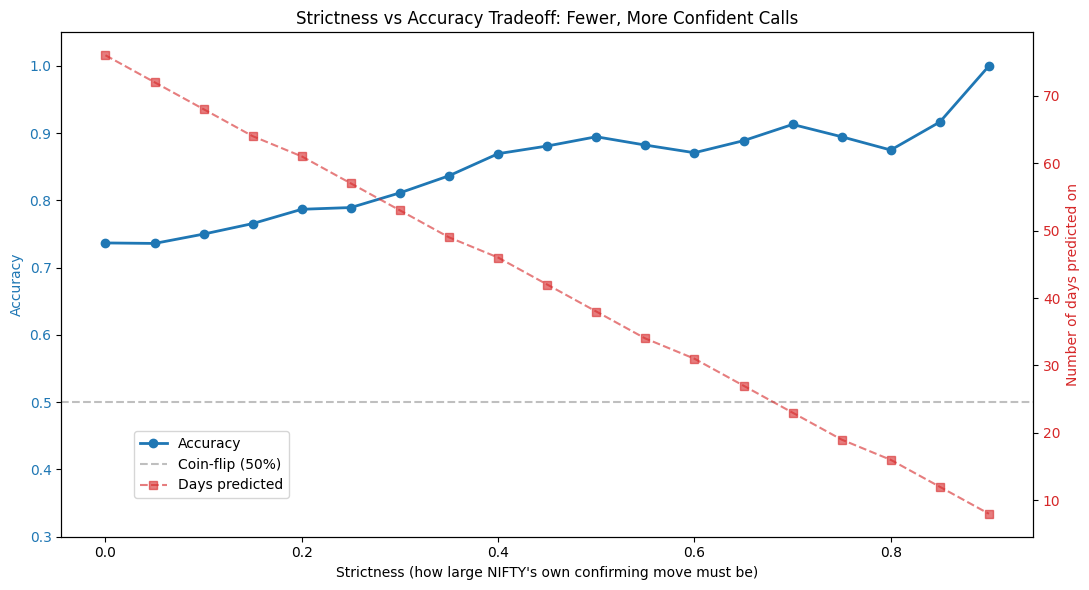

✓ As strictness increases (moving right), accuracy (blue) climbs while
  the number of days you actually get to predict on (red) shrinks.
  Choose a point on this curve based on how much coverage you need
  versus how much accuracy you want.


In [3]:
# ==========================================
# CELL 3 — VISUALIZE THE TRADEOFF: ACCURACY vs DAYS PREDICTED
# ==========================================
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(11, 6))

color1 = "tab:blue"
ax1.set_xlabel("Strictness (how large NIFTY's own confirming move must be)")
ax1.set_ylabel("Accuracy", color=color1)
ax1.plot(sweep_df["strictness_quantile"], sweep_df["accuracy"], "o-", color=color1, linewidth=2, label="Accuracy")
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Coin-flip (50%)")
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_ylim(0.3, 1.05)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Number of days predicted on", color=color2)
ax2.plot(sweep_df["strictness_quantile"], sweep_df["n_days"], "s--", color=color2, alpha=0.6, label="Days predicted")
ax2.tick_params(axis="y", labelcolor=color2)

ax1.set_title("Strictness vs Accuracy Tradeoff: Fewer, More Confident Calls")
fig.legend(loc="lower left", bbox_to_anchor=(0.12, 0.15))
plt.tight_layout()
plt.savefig("strictness_accuracy_tradeoff.png", dpi=100)
plt.show()

print("✓ As strictness increases (moving right), accuracy (blue) climbs while")
print("  the number of days you actually get to predict on (red) shrinks.")
print("  Choose a point on this curve based on how much coverage you need")
print("  versus how much accuracy you want.")

In [4]:
# ==========================================
# CELL 4 — SAME TRADEOFF, YEAR BY YEAR (STABILITY ACROSS THE SWEEP)
# ==========================================
# The aggregate curve above could hide instability - e.g. if all the gains
# came from one great year. We check the accuracy trend at three strictness
# levels (loose / medium / strict) broken out by year.

print("=== STRICTNESS LEVELS BROKEN OUT BY YEAR ===")

def strictness_by_year(quantile_level, label):
    thresh = agree_days["NIFTY_prev_return"].abs().quantile(quantile_level)
    subset = agree_days[agree_days["NIFTY_prev_return"].abs() >= thresh].copy()
    subset["year"] = subset["Date"].dt.year
    yearly = subset.groupby("year")["rule_correct"].agg(["size", "mean"])
    print(f"\n--- {label} (quantile={quantile_level}, n={len(subset)}) ---")
    print(yearly.rename(columns={"size": "n", "mean": "accuracy"}))
    return yearly

loose = strictness_by_year(0.0, "LOOSE (full agree bucket, no extra filter)")
medium = strictness_by_year(0.5, "MEDIUM (median NIFTY move size)")
strict = strictness_by_year(0.75, "STRICT (top quartile NIFTY move size)")

=== STRICTNESS LEVELS BROKEN OUT BY YEAR ===

--- LOOSE (full agree bucket, no extra filter) (quantile=0.0, n=76) ---
       n  accuracy
year              
2021  11  0.818182
2022  18  0.944444
2023  13  0.692308
2024  16  0.812500
2025  18  0.444444

--- MEDIUM (median NIFTY move size) (quantile=0.5, n=38) ---
       n  accuracy
year              
2021   7  0.857143
2022  15  0.933333
2023   4  1.000000
2024   7  0.857143
2025   5  0.800000

--- STRICT (top quartile NIFTY move size) (quantile=0.75, n=19) ---
      n  accuracy
year             
2021  5  0.800000
2022  9  0.888889
2024  3  1.000000
2025  2  1.000000


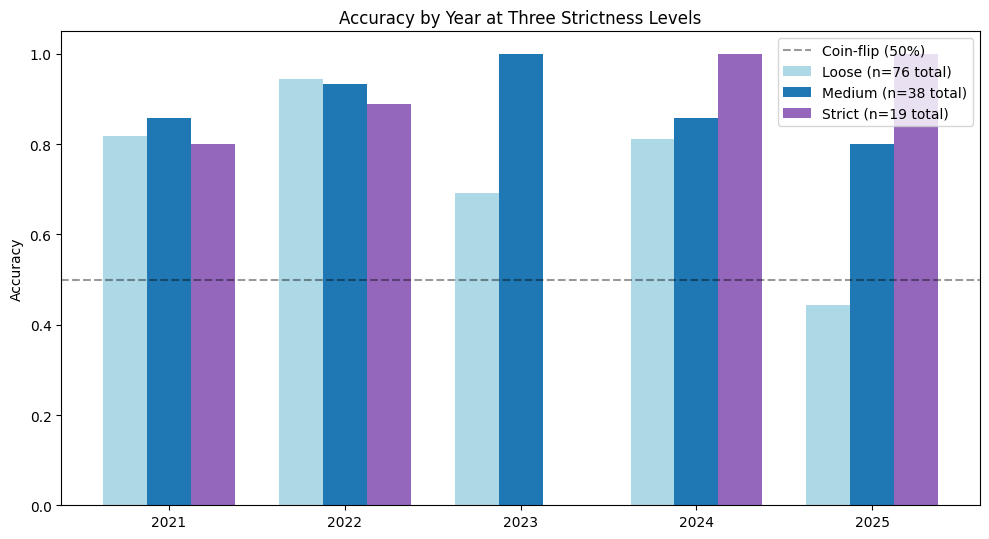

✓ If purple bars (strict) are consistently at or above blue (medium)
  and light blue (loose) across MOST years, the strictness increase is
  genuinely helping broadly, not just in one lucky year.


In [5]:
# ==========================================
# CELL 5 — VISUALIZE YEAR-BY-YEAR ACCURACY AT EACH STRICTNESS LEVEL
# ==========================================
fig, ax = plt.subplots(figsize=(10, 5.5))

years = sorted(set(loose.index) | set(medium.index) | set(strict.index))
x = np.arange(len(years))
width = 0.25

vals_loose = [loose["mean"].get(y, np.nan) for y in years]
vals_medium = [medium["mean"].get(y, np.nan) for y in years]
vals_strict = [strict["mean"].get(y, np.nan) for y in years]

ax.bar(x - width, vals_loose, width, label="Loose (n=76 total)", color="lightblue")
ax.bar(x, vals_medium, width, label="Medium (n=38 total)", color="tab:blue")
ax.bar(x + width, vals_strict, width, label="Strict (n=19 total)", color="tab:purple")

ax.axhline(0.5, color="black", linestyle="--", alpha=0.4, label="Coin-flip (50%)")
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Year at Three Strictness Levels")
ax.legend()

plt.tight_layout()
plt.savefig("strictness_by_year.png", dpi=100)
plt.show()

print("✓ If purple bars (strict) are consistently at or above blue (medium)")
print("  and light blue (loose) across MOST years, the strictness increase is")
print("  genuinely helping broadly, not just in one lucky year.")

In [6]:
# ==========================================
# CELL 6 — FEATURE REFERENCE TABLE
# ==========================================
# Every feature used anywhere in this notebook (and in notebook 9), what it
# represents, where it's computed from, and what role it plays.

feature_reference = pd.DataFrame([
    {"Feature": "US_SP500_prev_return", "Source": "sp500_daily.csv", "Meaning": "Previous US trading day's S&P 500 log return", "Role": "Cross-market spillover signal (secondary - US VIX proved more stable)"},
    {"Feature": "US_VIX_prev_close", "Source": "vix_us_daily.csv", "Meaning": "Previous US trading day's VIX closing level", "Role": "Regime gate + prediction feature"},
    {"Feature": "US_VIX_prev_chg1d", "Source": "vix_us_daily.csv", "Meaning": "Previous US trading day's VIX change", "Role": "PRIMARY signal - used for regime gate AND the prediction rule itself"},
    {"Feature": "SKEW_30D_prev / SKEW_14D_prev", "Source": "daily_volatility_features.csv", "Meaning": "Yesterday's NIFTY put/call IV skew (30D, 14D)", "Role": "Tested addition - did not improve accuracy in practice"},
    {"Feature": "India_VIX_prev_close / _chg1d", "Source": "hist_india_vix_*.csv", "Meaning": "Yesterday's India VIX level and change", "Role": "Tested addition - weaker standalone signal than US VIX (56% vs 62% accuracy)"},
    {"Feature": "NIFTY_prev_return", "Source": "FUTIDX_NIFTY_*.csv (Underlying Value)", "Meaning": "NIFTY's own previous-day log return", "Role": "CONFIRMATION signal - used to classify agree/disagree/neutral, and as the strictness-sweep variable"},
    {"Feature": "ATM_IV_30D_prev", "Source": "daily_volatility_features.csv", "Meaning": "Yesterday's NIFTY 30-day ATM implied volatility", "Role": "Used to compute the target (NIFTY_IV_chg1d), not as an input feature here"},
    {"Feature": "rolling_corr_60", "Source": "Computed live from US_SP500_prev_return + NIFTY_prev_return", "Meaning": "60-day rolling correlation between US and NIFTY returns", "Role": "Tested regime detector - explains 2025 weakness but too little data to use as a model feature"},
])

pd.set_option("display.max_colwidth", 80)
print("=== FEATURE REFERENCE TABLE ===\n")
print(feature_reference.to_string(index=False))

feature_reference.to_csv("feature_reference.csv", index=False)
print("\n✓ Saved to feature_reference.csv")

=== FEATURE REFERENCE TABLE ===

                      Feature                                                      Source                                                 Meaning                                                                                                Role
         US_SP500_prev_return                                             sp500_daily.csv            Previous US trading day's S&P 500 log return                               Cross-market spillover signal (secondary - US VIX proved more stable)
            US_VIX_prev_close                                            vix_us_daily.csv             Previous US trading day's VIX closing level                                                                    Regime gate + prediction feature
            US_VIX_prev_chg1d                                            vix_us_daily.csv                    Previous US trading day's VIX change                                PRIMARY signal - used for regime gate AND the predic

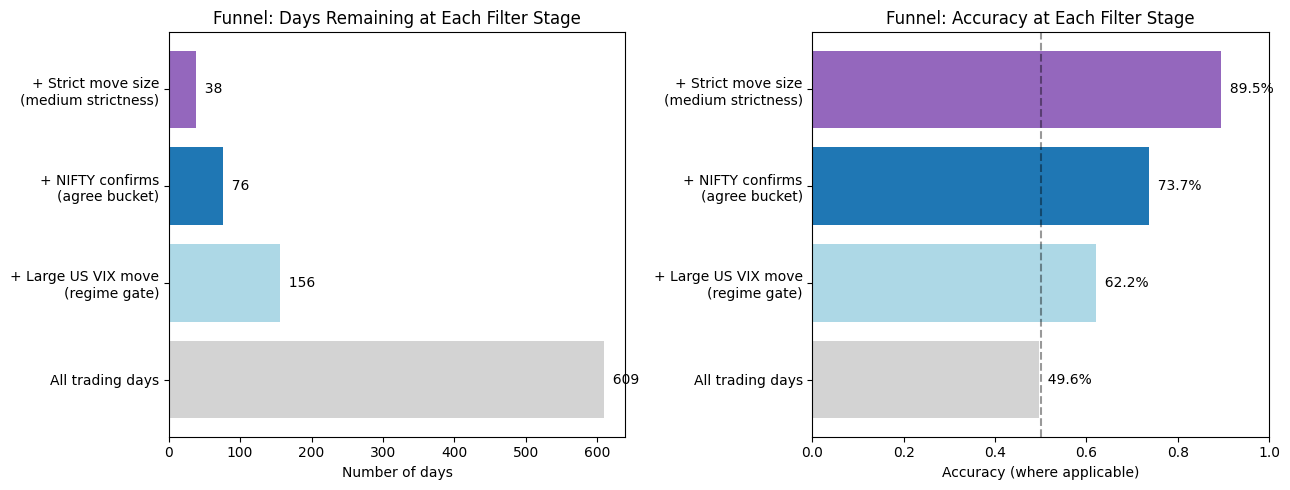

✓ Each stage narrows the days you predict on, but raises the accuracy
  on the days you DO choose to call.


In [7]:
# ==========================================
# CELL 7 — VISUALIZE THE FUNNEL: HOW EACH FILTER REDUCES DAYS AND RAISES ACCURACY
# ==========================================
funnel_stages = [
    ("All trading days", len(full_df), full_df[TARGET_COL].mean()),
    ("+ Large US VIX move\n(regime gate)", len(flagged_df), flagged_df["rule_correct"].mean()),
    ("+ NIFTY confirms\n(agree bucket)", len(agree_days), agree_days["rule_correct"].mean()),
    ("+ Strict move size\n(medium strictness)", medium["size"].sum(), (medium["size"] * medium["mean"]).sum() / medium["size"].sum()),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = [s[0] for s in funnel_stages]
counts = [s[1] for s in funnel_stages]
accs = [s[2] for s in funnel_stages]

axes[0].barh(labels, counts, color=["lightgray", "lightblue", "tab:blue", "tab:purple"])
axes[0].set_xlabel("Number of days")
axes[0].set_title("Funnel: Days Remaining at Each Filter Stage")
for i, c in enumerate(counts):
    axes[0].text(c, i, f"  {c:.0f}", va="center")

axes[1].barh(labels, accs, color=["lightgray", "lightblue", "tab:blue", "tab:purple"])
axes[1].axvline(0.5, color="black", linestyle="--", alpha=0.4)
axes[1].set_xlabel("Accuracy (where applicable)")
axes[1].set_xlim(0, 1)
axes[1].set_title("Funnel: Accuracy at Each Filter Stage")
for i, a in enumerate(accs):
    axes[1].text(a, i, f"  {a:.1%}", va="center")

plt.tight_layout()
plt.savefig("filter_funnel.png", dpi=100)
plt.show()

print("✓ Each stage narrows the days you predict on, but raises the accuracy")
print("  on the days you DO choose to call.")